In [43]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
drive.mount('/content/drive')

STAR_SCHEMA_DIR = '/content/drive/MyDrive/My Project/E-Commerce Data Modeling & Customer Lifetime Value Analytics/data/star_schema'
MODEL_OUTPUT_DIR = '/content/drive/MyDrive/My Project/E-Commerce Data Modeling & Customer Lifetime Value Analytics/data/model'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
Fact_Orders = pd.read_csv(f'{STAR_SCHEMA_DIR}/Fact_Orders.csv')
Dim_Customer = pd.read_csv(f'{STAR_SCHEMA_DIR}/Dim_Customer.csv')
Dim_Product = pd.read_csv(f'{STAR_SCHEMA_DIR}/Dim_Product.csv')

In [46]:
Fact_Orders['order_date'] = pd.to_datetime(Fact_Orders['order_date_key'].astype(str), format='%Y%m%d')

df_analytics = Fact_Orders.merge(Dim_Customer[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='inner')
max_date = df_analytics['order_date'].max() + pd.Timedelta(days=1)

In [47]:
customer_rfm = df_analytics.groupby('customer_unique_id').agg(
    Last_Purchase_Date=('order_date', 'max'),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum'),
    Freight_Spent=('freight_value', 'sum')
).reset_index()

In [48]:
customer_rfm['Recency'] = (max_date - customer_rfm['Last_Purchase_Date']).dt.days
customer_rfm['Historical_CLV'] = customer_rfm['Monetary'] + customer_rfm['Freight_Spent']

customer_rfm['R_Score'] = pd.qcut(customer_rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)
customer_rfm['M_Score'] = pd.qcut(customer_rfm['Historical_CLV'], q=5, labels=False, duplicates='drop') + 1
customer_rfm['F_Score'] = np.where(customer_rfm['Frequency'] == 1, 1, 5)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(customer_rfm[['Recency', 'Frequency', 'Monetary']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_rfm['ML_Cluster'] = kmeans.fit_predict(rfm_scaled)

In [49]:
def assign_segment(row):
    if row['Frequency'] == 1:
        if row['M_Score'] >= 4:
            return 'One-Time Buyer (High Value)'
        elif row['M_Score'] == 3:
            return 'One-Time Buyer (Medium Value)'
        else:
            return 'One-Time Buyer (Low Value)'
    else:
        if row['M_Score'] >= 4:
            return 'Repeat Customer (High Value)'
        else:
            return 'Repeat Customer (Core Value)'

In [50]:
customer_rfm['segment_label'] = customer_rfm.apply(assign_segment, axis=1)
print(f"Phân bố các phân khúc khách hàng:\n{customer_rfm['segment_label'].value_counts()}")

Phân bố các phân khúc khách hàng:
segment_label
One-Time Buyer (Low Value)       37981
One-Time Buyer (High Value)      35848
One-Time Buyer (Medium Value)    18678
Repeat Customer (High Value)      2317
Repeat Customer (Core Value)       596
Name: count, dtype: int64


In [52]:
order_level_data = df_analytics.groupby(['customer_unique_id', 'order_id']).agg(
    order_date=('order_date', 'first'),
    first_order_value=('payment_value', 'sum'),
    first_freight_value=('freight_value', 'sum'),
    review_score=('review_score', 'first'),
    customer_state=('customer_state', 'first'),
    product_id=('product_id', 'first')
).reset_index()

In [53]:
order_level_data = order_level_data.sort_values('order_date')
first_orders = order_level_data.groupby('customer_unique_id').first().reset_index()

df_model = first_orders.merge(Dim_Product[['product_id', 'product_category_name']], on='product_id', how='left')
df_model['product_category_name'] = df_model['product_category_name'].fillna('other')
df_model.drop(columns=['product_id', 'order_id'], inplace=True)

In [54]:
df_model = df_model.merge(customer_rfm[['customer_unique_id', 'Frequency']], on='customer_unique_id', how='left')
df_model['is_repeat_customer'] = np.where(df_model['Frequency'] > 1, 1, 0)
df_model.drop(columns=['Frequency'], inplace=True)

df_model['review_score'] = df_model['review_score'].fillna(df_model['review_score'].median())

In [55]:
df_encoded = pd.get_dummies(df_model, columns=['customer_state', 'product_category_name'], drop_first=True)

X = df_encoded.drop(columns=['customer_unique_id', 'order_date', 'is_repeat_customer'])
y = df_encoded['is_repeat_customer']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Số lượng nhãn tập Train trước SMOTE:\n{y_train.value_counts()}")
print(f"Số lượng nhãn tập Train sau SMOTE:\n{y_train_smote.value_counts()}")

Số lượng nhãn tập Train trước SMOTE:
is_repeat_customer
0    74006
1     2330
Name: count, dtype: int64
Số lượng nhãn tập Train sau SMOTE:
is_repeat_customer
0    74006
1    74006
Name: count, dtype: int64


In [57]:
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=2,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [59]:
y_pred_prob = model_xgb.predict_proba(X_test)[:, 1]

CUSTOM_THRESHOLD = 0.35
y_pred_custom = (y_pred_prob >= CUSTOM_THRESHOLD).astype(int)

print(f"Chỉ số AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"Classification Report (Ngưỡng {CUSTOM_THRESHOLD}):")
print(classification_report(y_test, y_pred_custom, target_names=['One-Time Buyer', 'Repeat Customer']))

Chỉ số AUC-ROC Score: 0.5879
Classification Report (Ngưỡng 0.35):
                 precision    recall  f1-score   support

 One-Time Buyer       0.98      0.42      0.59     18501
Repeat Customer       0.04      0.71      0.07       583

       accuracy                           0.43     19084
      macro avg       0.51      0.56      0.33     19084
   weighted avg       0.95      0.43      0.57     19084



In [60]:
df_model['repeat_purchase_probability'] = model_xgb.predict_proba(X)[:, 1]

In [61]:
Customer_Segments = customer_rfm[['customer_unique_id', 'Recency', 'Frequency', 'Historical_CLV', 'R_Score', 'F_Score', 'M_Score', 'ML_Cluster', 'segment_label']]
Customer_Segments.to_csv(f'{MODEL_OUTPUT_DIR}/Customer_Segments.csv', index=False)

In [64]:
Dim_Customer_Updated = Dim_Customer.drop(columns=['customer_segment', 'ml_cluster'], errors='ignore').merge(
    customer_rfm[['customer_unique_id', 'segment_label', 'ML_Cluster']], on='customer_unique_id', how='left')
Dim_Customer_Updated.rename(columns={'segment_label': 'customer_segment', 'ML_Cluster': 'ml_cluster'}, inplace=True)
Dim_Customer_Updated['customer_segment'] = Dim_Customer_Updated['customer_segment'].fillna('One-Time Buyer (Low Value)')
Dim_Customer_Updated['ml_cluster'] = Dim_Customer_Updated['ml_cluster'].fillna(-1)
Dim_Customer_Updated.to_csv(f'{STAR_SCHEMA_DIR}/Dim_Customer.csv', index=False)

In [65]:
Repeat_Purchase_Prediction = df_model[['customer_unique_id', 'repeat_purchase_probability', 'is_repeat_customer']].copy()
Repeat_Purchase_Prediction['risk_segment'] = pd.qcut(Repeat_Purchase_Prediction['repeat_purchase_probability'], q=3, labels=['Low Potential', 'Medium Potential', 'High Potential'], duplicates='drop')
Repeat_Purchase_Prediction.to_csv(f'{MODEL_OUTPUT_DIR}/Repeat_Purchase_Prediction.csv', index=False)

In [66]:
importances = model_xgb.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [67]:
print("Top 10 Feature Quan Trọng Nhất:")
print(feature_importance_df.head(10))

Top 10 Feature Quan Trọng Nhất:
                                           Feature  Importance
2                                     review_score    0.084880
56  product_category_name_fashion_bags_accessories    0.050156
72           product_category_name_home_appliances    0.038686
24                               customer_state_RS    0.035258
6                                customer_state_BA    0.032265
10                               customer_state_GO    0.031960
20                               customer_state_RJ    0.031570
12                               customer_state_MG    0.030357
9                                customer_state_ES    0.028890
67           product_category_name_furniture_decor    0.028226


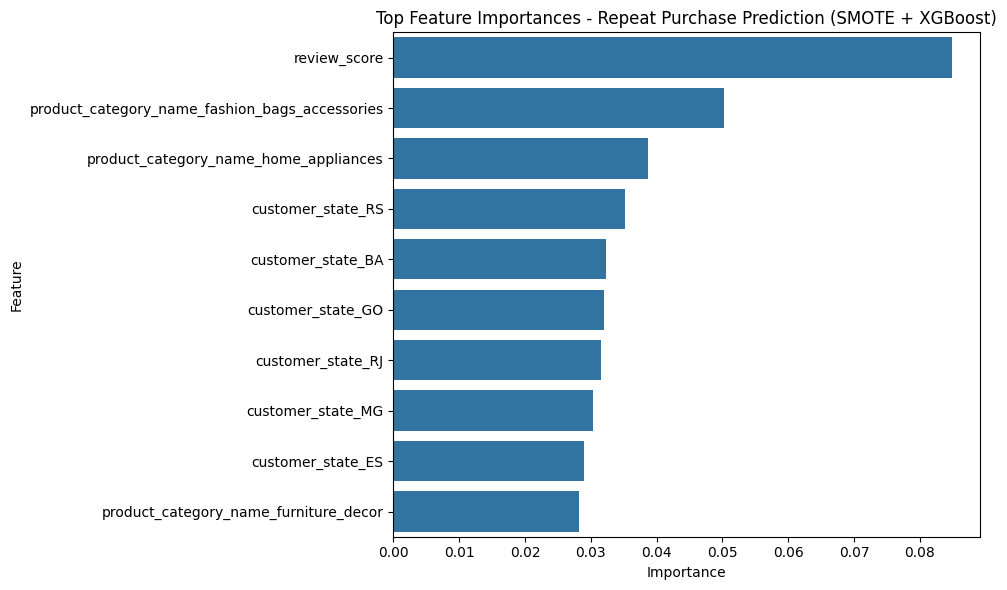

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top Feature Importances - Repeat Purchase Prediction (SMOTE + XGBoost)')
plt.tight_layout()
plt.show()